# Statistical Inference — London Bike Rentals

## 0. Overview

**Business context:** You are a data analyst at a London bike rental company. A colleague has shared two years of hourly rental data collected across the city.

**Dataset:** `london.csv`
- Period: 4 January 2015 – 3 January 2017 (hourly records)
- Key columns: `timestamp`, `cnt` (rental count), `t1` (real temperature °C), `t2` (feels-like temperature °C), `hum` (humidity %), `wind_speed` (km/h), `weather_code`, `is_holiday`, `is_weekend`, `season`

**Goal:** Detect anomalous days using a rolling-mean baseline and a 99% confidence interval, then investigate the root cause of each anomaly.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/london.csv")
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [4]:
print(df.shape)
df.info()

(17414, 10)
<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  str    
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), str(1)
memory usage: 1.3 MB


In [4]:
df.describe()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


## 2. Data Cleaning

In [6]:
# Convert timestamp string to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Cast categorical columns from float to int
category_cols = ["weather_code", "is_holiday", "is_weekend", "season"]
df[category_cols] = df[category_cols].astype("int64")

# Set timestamp as the DataFrame index (required for .resample())
df = df.set_index("timestamp")

df.head()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,
2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3,0,1,3
2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1,0,1,3
2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1,0,1,3
2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1,0,1,3
2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1,0,1,3


In [7]:
# Verify no missing values
df.isna().sum()

cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

In [7]:
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)
print(f"Duplicate rows remaining: {df.duplicated().sum()}")

Duplicate rows remaining: 0


## 3. Exploratory Visualization

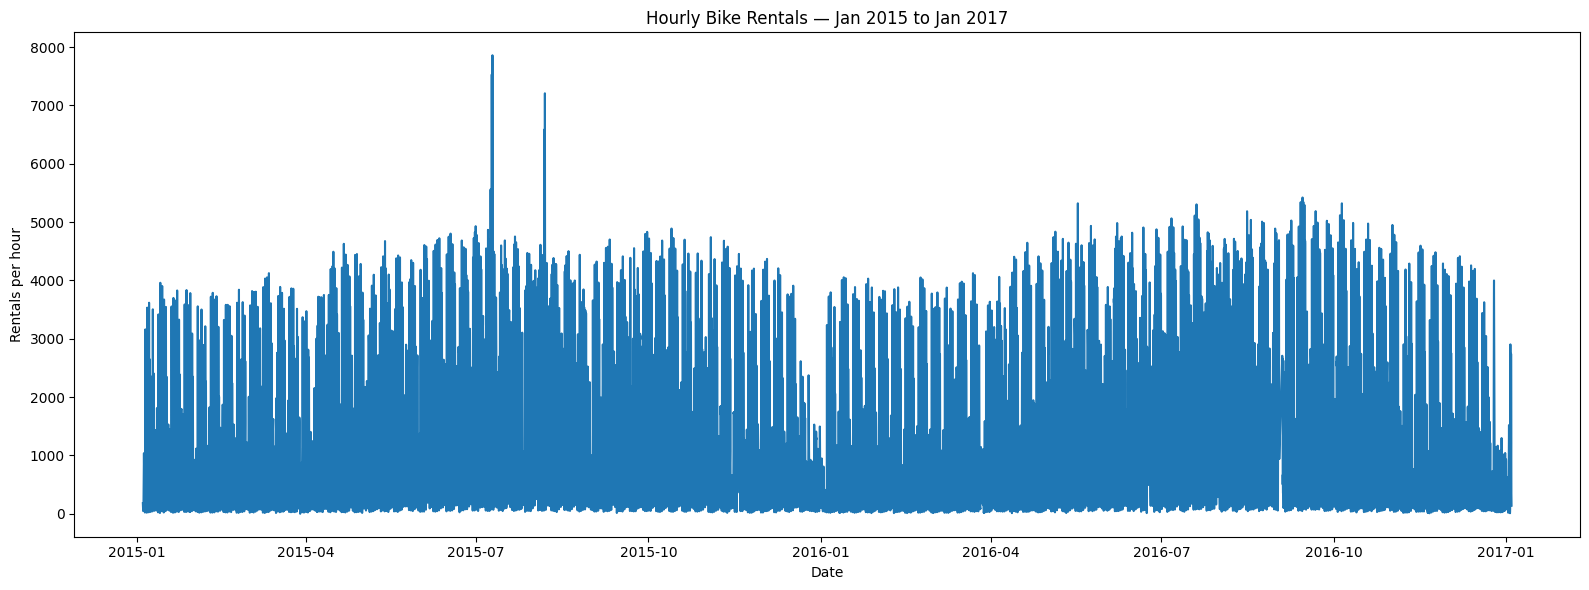

In [8]:
# Hourly rental counts over the full two-year period
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df.index, y=df["cnt"], ax=ax)
ax.set_title("Hourly Bike Rentals — Jan 2015 to Jan 2017")
ax.set_xlabel("Date")
ax.set_ylabel("Rentals per hour")
plt.tight_layout()
plt.show()

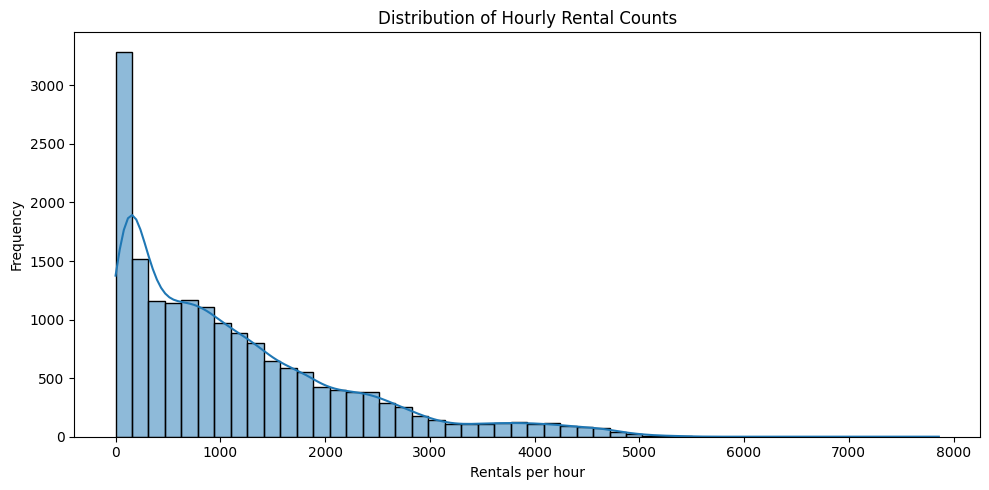

In [9]:
# Distribution of hourly rental counts
# Understanding the shape before aggregating helps interpret daily totals
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["cnt"], bins=50, kde=True, ax=ax)
ax.set_title("Distribution of Hourly Rental Counts")
ax.set_xlabel("Rentals per hour")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Daily Aggregation

In [10]:
# Aggregate hourly data to daily sums
df_daily = df.resample(rule="D").sum()
df_daily.head()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,
2015-01-04,9234,59.5,15.5,2262.5,180.0,69,0,24,72
2015-01-05,20372,193.0,161.0,1927.5,212.5,80,0,0,72
2015-01-06,20613,188.5,128.0,1893.5,384.0,74,0,0,72
2015-01-07,21064,171.5,103.5,1796.5,454.5,60,0,0,69
2015-01-08,15601,234.0,187.0,1903.5,491.5,84,0,0,72


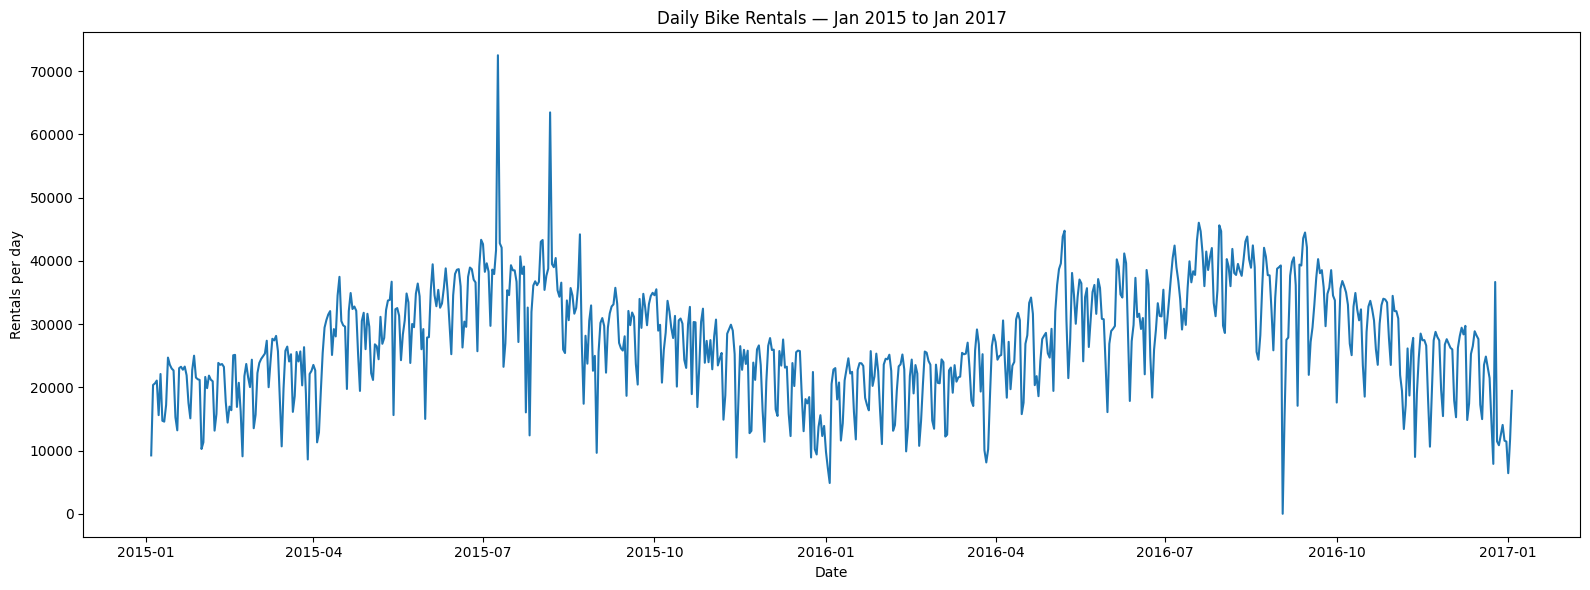

In [11]:
# Daily total rentals time series
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["cnt"], ax=ax)
ax.set_title("Daily Bike Rentals — Jan 2015 to Jan 2017")
ax.set_xlabel("Date")
ax.set_ylabel("Rentals per day")
plt.tight_layout()
plt.show()

## 5. Rolling Average & Residuals

**Theory:** A *rolling mean* (moving average) smooths a time series by replacing each value with the average of its surrounding window. Here we use a window of 3 days — each day's expected value is estimated as the average of that day and the two preceding days.

The *residual* is the difference between the observed value and the rolling mean:
$$\text{residual}_t = \text{cnt}_t - \overline{\text{cnt}}_t$$

Large residuals signal that a day was unusual relative to recent history.

In [11]:
# Rolling mean with a 3-day window
df_daily["cnt_rolling"] = df_daily["cnt"].rolling(window=3).mean()

# Residuals: actual minus expected
df_daily["cnt_diff"] = df_daily["cnt"] - df_daily["cnt_rolling"]

# Standard deviation of residuals — measures typical deviation from the rolling baseline
std = np.std(df_daily["cnt_diff"])
print(f"Std of residuals: {std:.2f}")

# Sanity check: rolling mean for 2015-07-09
print(f"Rolling mean on 2015-07-09: {df_daily.loc['2015-07-09', 'cnt_rolling']:.0f}")

Std of residuals: 4558.59
Rolling mean on 2015-07-09: 50705


## 6. Confidence Interval & Anomaly Bounds

**Theory:** A 99% confidence interval uses the z-score **z = 2.576**. Assuming residuals are approximately normally distributed, the bounds around the rolling mean are:

$$\text{upper\_bound}_t = \overline{\text{cnt}}_t + 2.576 \times \sigma$$
$$\text{lower\_bound}_t = \overline{\text{cnt}}_t - 2.576 \times \sigma$$

Any day whose actual rental count falls **outside** these bounds is flagged as statistically anomalous at the 99% confidence level.

In [12]:
# Compute upper and lower bounds
df_daily["upper_bound"] = df_daily["cnt_rolling"] + 2.576 * std
df_daily["lower_bound"] = df_daily["cnt_rolling"] - 2.576 * std

print(f"Upper bound on last observation: {df_daily['upper_bound'].iloc[-1]:.2f}")

Upper bound on last observation: 24302.92


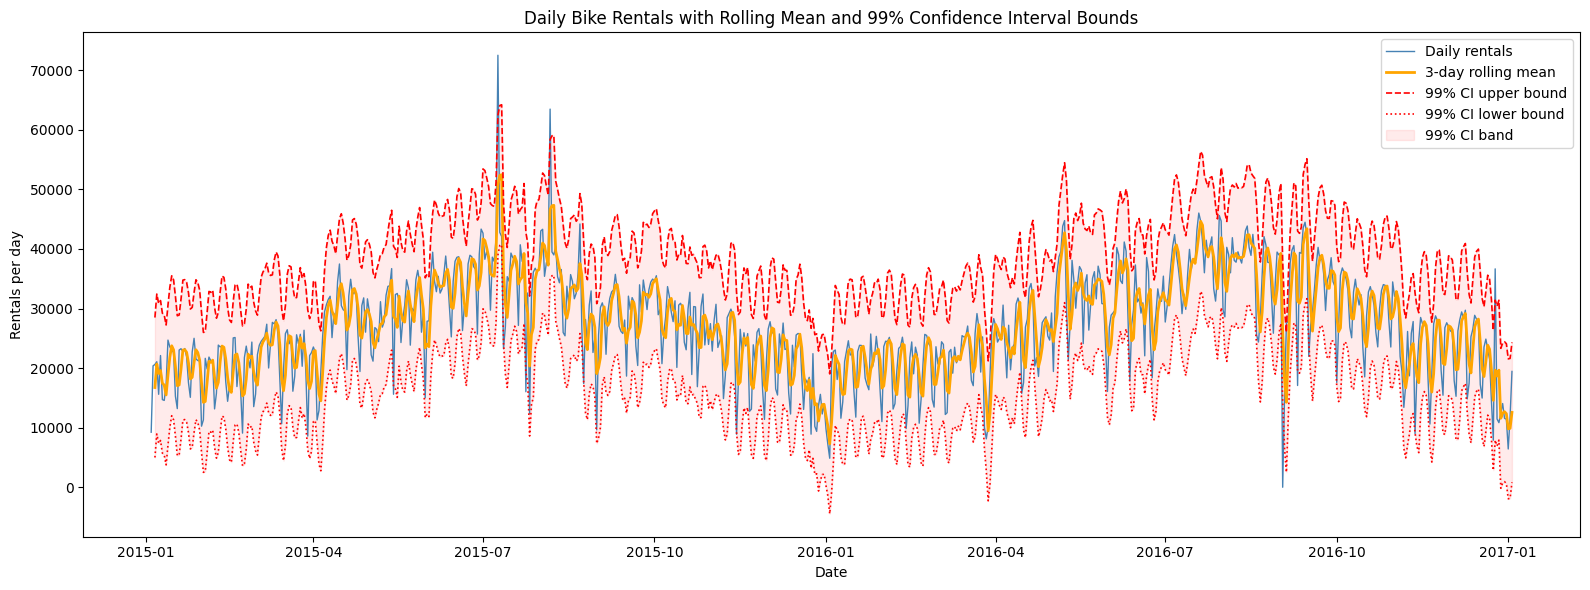

In [13]:
# Combined plot: daily rentals + rolling mean + 99% CI bounds
# This is the key visualization — anomalies are days that pierce the upper or lower band
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df_daily.index, df_daily["cnt"], color="steelblue", lw=1, label="Daily rentals")
ax.plot(df_daily.index, df_daily["cnt_rolling"], color="orange", lw=2, label="3-day rolling mean")
ax.plot(df_daily.index, df_daily["upper_bound"], color="red", lw=1.2, linestyle="--", label="99% CI upper bound")
ax.plot(df_daily.index, df_daily["lower_bound"], color="red", lw=1.2, linestyle=":", label="99% CI lower bound")

# Shade the confidence band
ax.fill_between(df_daily.index, df_daily["lower_bound"], df_daily["upper_bound"],
                color="red", alpha=0.08, label="99% CI band")

ax.set_title("Daily Bike Rentals with Rolling Mean and 99% Confidence Interval Bounds")
ax.set_xlabel("Date")
ax.set_ylabel("Rentals per day")
ax.legend()
plt.tight_layout()
plt.show()

## 7. High Anomaly Investigation — 2015-07-09

In [14]:
# Days where actual rentals exceed the upper bound
high_anomalies = df_daily.query("cnt > upper_bound")
print(f"Number of high-anomaly days: {len(high_anomalies)}")

# Day with the highest rental count among anomalies
peak_date = high_anomalies["cnt"].idxmax()
peak_cnt = high_anomalies["cnt"].max()
print(f"Peak anomaly date: {peak_date.date()}, rentals: {peak_cnt:,}")

Number of high-anomaly days: 4
Peak anomaly date: 2015-07-09, rentals: 72,504


In [16]:
# Full row for the peak day
df_daily.loc["2015-07-09"]

cnt             72504.000000
t1                427.000000
t2                421.000000
hum              1175.500000
wind_speed        311.500000
weather_code       28.000000
is_holiday          0.000000
is_weekend          0.000000
season             24.000000
cnt_rolling     50705.000000
cnt_diff        21799.000000
upper_bound     62445.880097
lower_bound     38964.119903
Name: 2015-07-09 00:00:00, dtype: float64

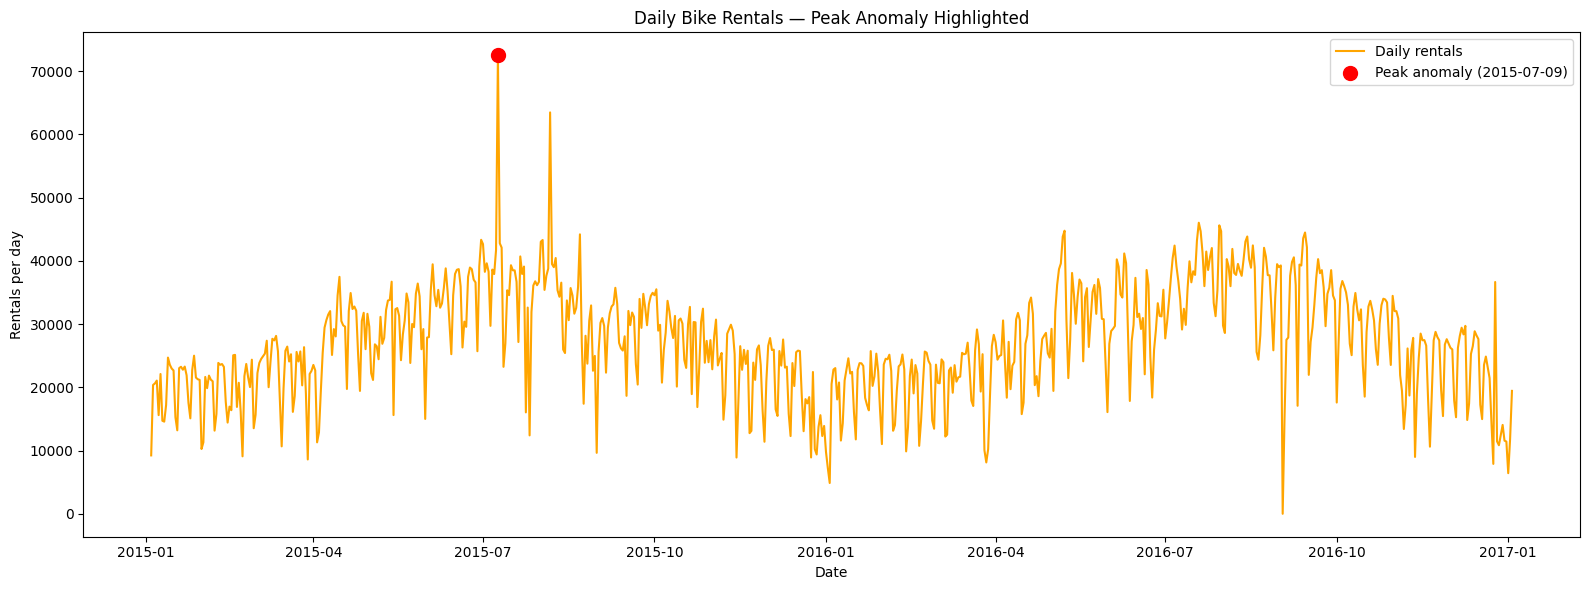

In [15]:
# Daily rentals with the peak anomaly highlighted
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["cnt"], color="orange", label="Daily rentals", ax=ax)
ax.scatter(peak_date, peak_cnt, color="red", s=100, zorder=5, label="Peak anomaly (2015-07-09)")
ax.set_title("Daily Bike Rentals — Peak Anomaly Highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Rentals per day")
ax.legend()
plt.tight_layout()
plt.show()

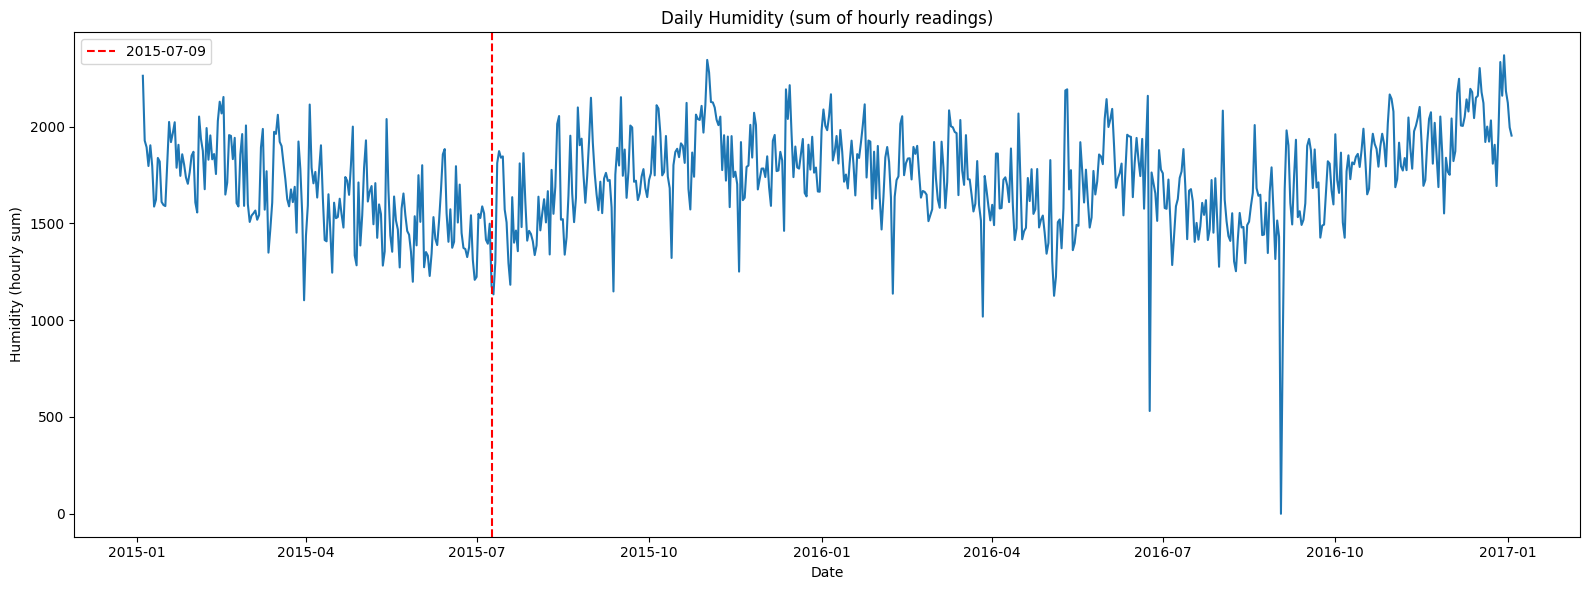

In [16]:
# Humidity around the anomaly date
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["hum"], ax=ax)
ax.axvline(pd.to_datetime("2015-07-09"), color="red", linestyle="--", label="2015-07-09")
ax.set_title("Daily Humidity (sum of hourly readings)")
ax.set_xlabel("Date")
ax.set_ylabel("Humidity (hourly sum)")
ax.legend()
plt.tight_layout()
plt.show()

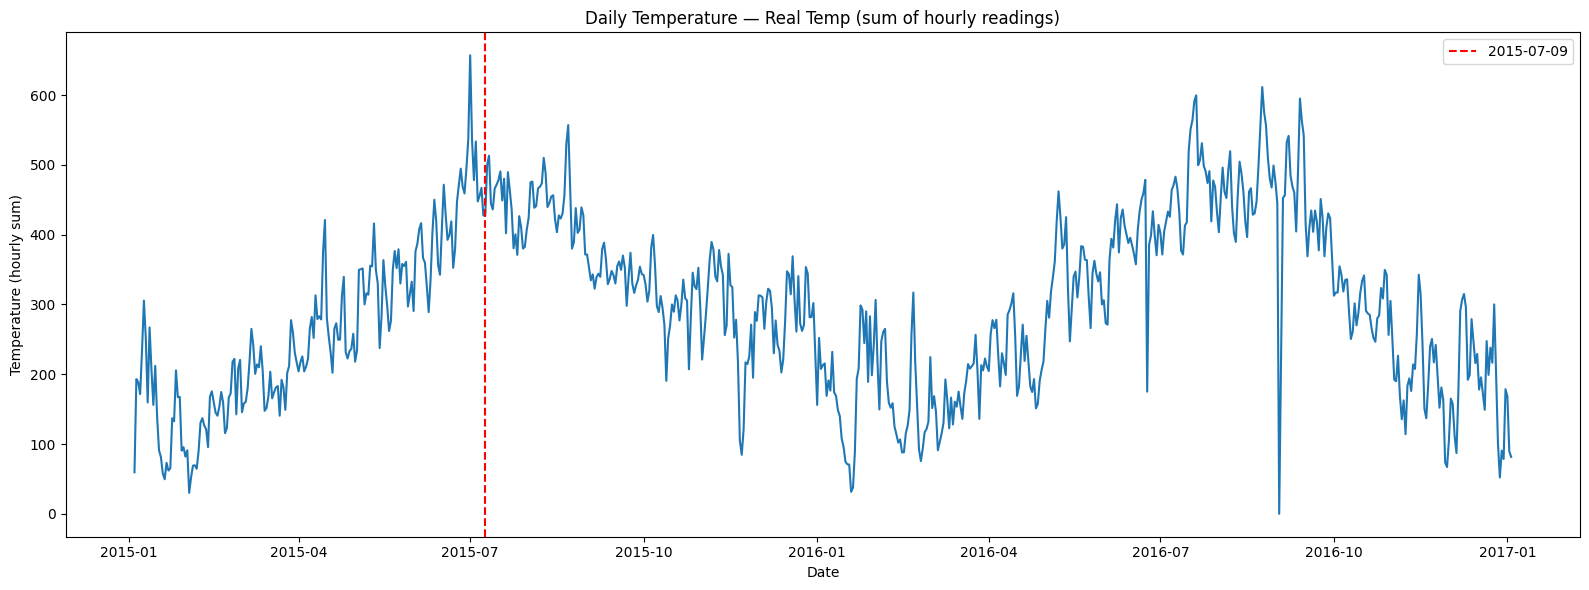

In [17]:
# Temperature around the anomaly date
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["t1"], ax=ax)
ax.axvline(pd.to_datetime("2015-07-09"), color="red", linestyle="--", label="2015-07-09")
ax.set_title("Daily Temperature — Real Temp (sum of hourly readings)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (hourly sum)")
ax.legend()
plt.tight_layout()
plt.show()

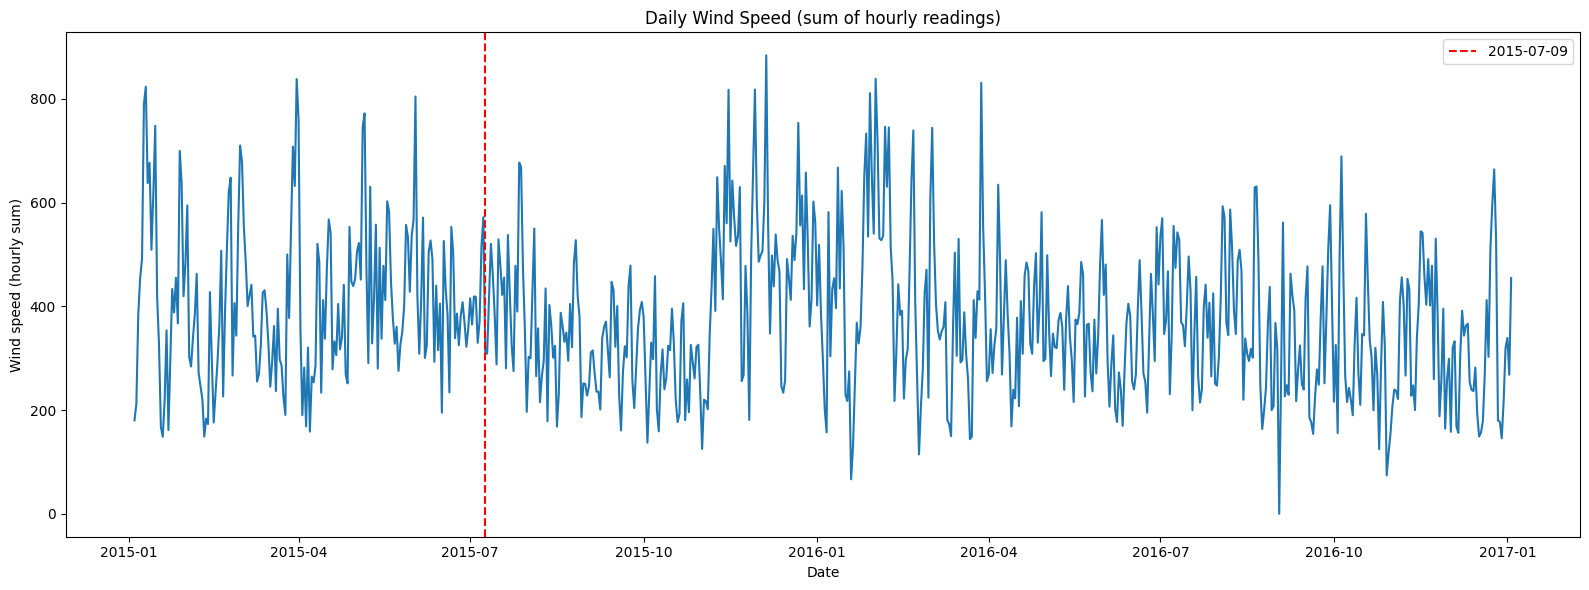

In [18]:
# Wind speed around the anomaly date
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["wind_speed"], ax=ax)
ax.axvline(pd.to_datetime("2015-07-09"), color="red", linestyle="--", label="2015-07-09")
ax.set_title("Daily Wind Speed (sum of hourly readings)")
ax.set_xlabel("Date")
ax.set_ylabel("Wind speed (hourly sum)")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion — 2015-07-09:**  
Rentals reached **72,504** — well above the 99% CI upper bound of ~62,446. Weather variables (temperature, humidity, wind) show no unusual values for that day, so the spike is **not a data artifact**. July 9, 2015 was a Thursday with normal weather — the most likely explanation is a major public event or promotion in London that drove an exceptional number of rides.

## 8. Low Anomaly Investigation — 2016-09-02

In [19]:
# Days where actual rentals fall below the lower bound
low_anomalies = df_daily.query("cnt < lower_bound")
print(f"Number of low-anomaly days: {len(low_anomalies)}")

# Day with the lowest rental count among anomalies
low_date = low_anomalies["cnt"].idxmin()
low_cnt = low_anomalies["cnt"].min()
print(f"Trough anomaly date: {low_date.date()}, rentals: {low_cnt:,}")

Number of low-anomaly days: 9
Trough anomaly date: 2016-09-02, rentals: 0


In [ ]:
# Full row for the trough day
df_daily.loc["2016-09-02"]

In [ ]:
# Daily rentals with the trough anomaly highlighted
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["cnt"], color="orange", label="Daily rentals", ax=ax)
ax.scatter(low_date, low_cnt, color="red", s=100, zorder=5, label="Trough anomaly (2016-09-02)")
ax.set_title("Daily Bike Rentals — Trough Anomaly Highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Rentals per day")
ax.legend()
plt.tight_layout()
plt.show()

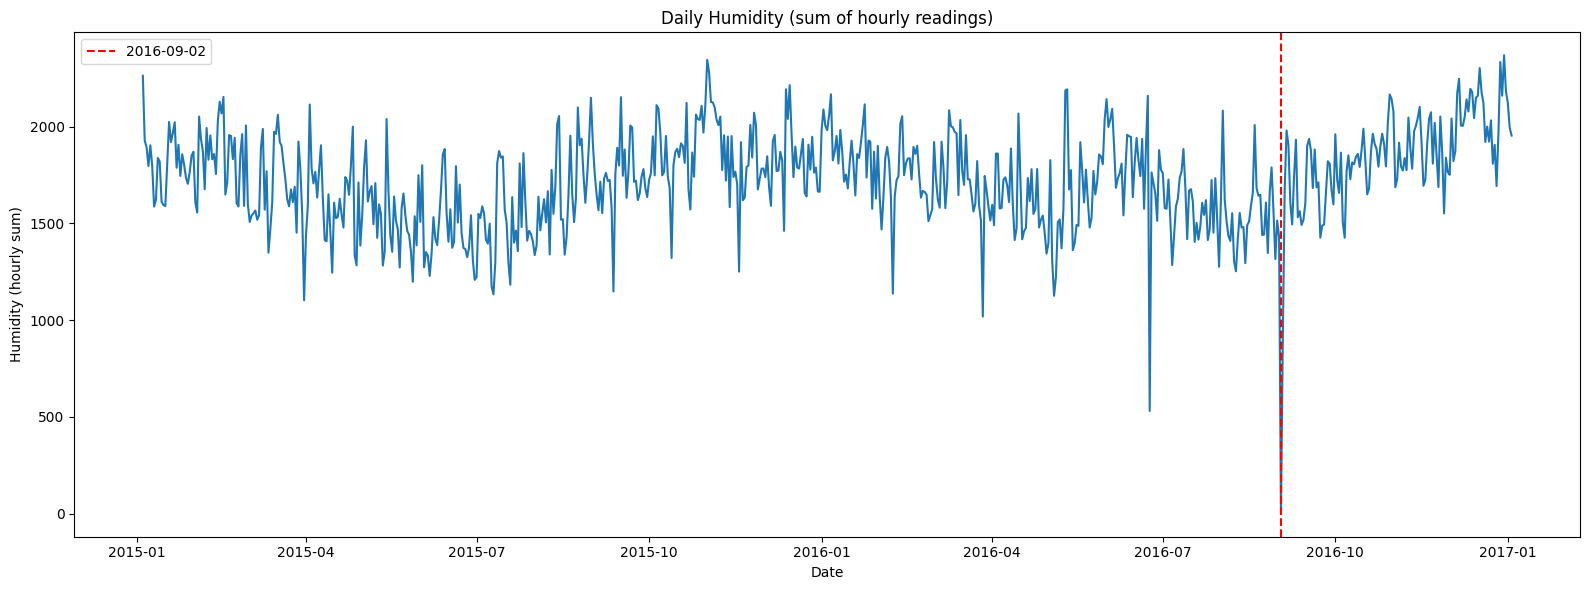

In [20]:
# Humidity around the trough date
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["hum"], ax=ax)
ax.axvline(low_date, color="red", linestyle="--", label="2016-09-02")
ax.set_title("Daily Humidity (sum of hourly readings)")
ax.set_xlabel("Date")
ax.set_ylabel("Humidity (hourly sum)")
ax.legend()
plt.tight_layout()
plt.show()

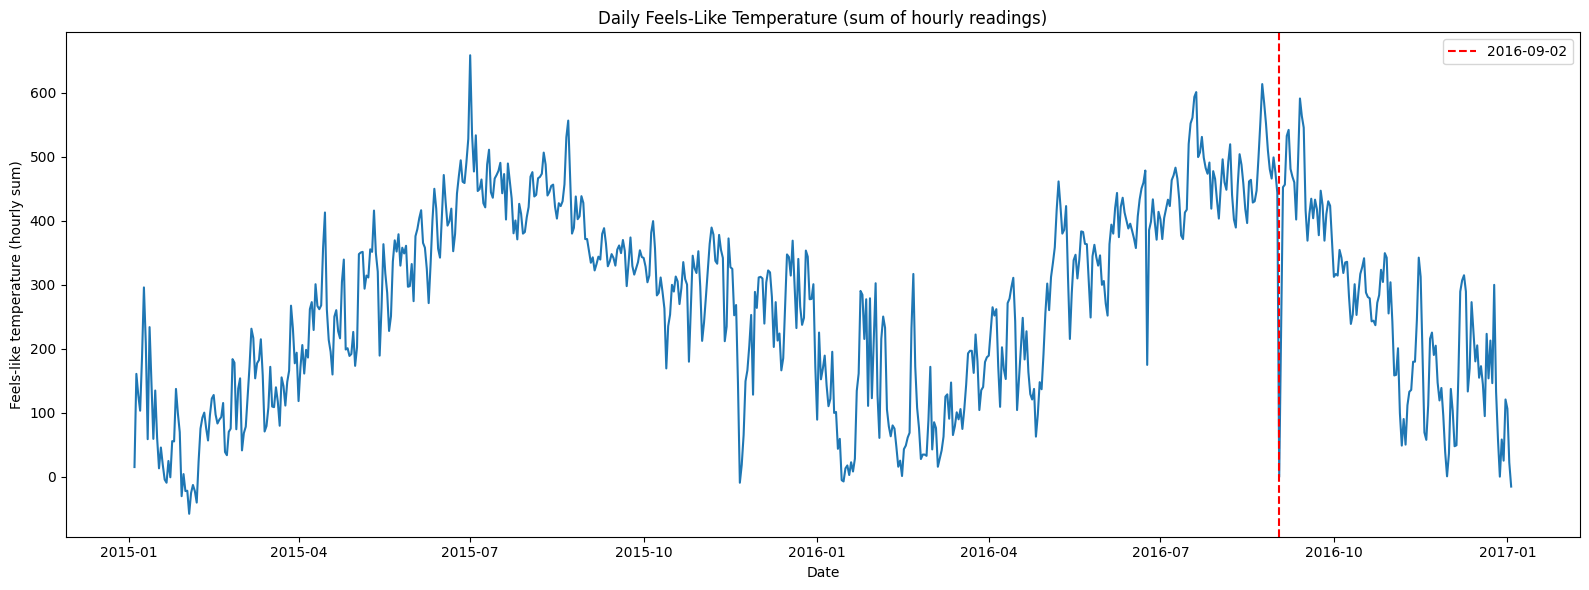

In [21]:
# Temperature around the trough date
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x=df_daily.index, y=df_daily["t2"], ax=ax)
ax.axvline(low_date, color="red", linestyle="--", label="2016-09-02")
ax.set_title("Daily Feels-Like Temperature (sum of hourly readings)")
ax.set_xlabel("Date")
ax.set_ylabel("Feels-like temperature (hourly sum)")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion — 2016-09-02:**  
Rentals = **0** on that day — and every other variable (temperature, humidity, wind speed, weather code) also equals **0**. This is a strong indicator of a **data collection failure**: no sensors reported any readings for the entire day. The anomaly is a data artifact, not a real-world event.

## 9. Summary

### Anomaly summary table

| Date | Direction | Rentals | 99% CI bound | Conclusion |
|------|-----------|---------|--------------|------------|
| 2015-07-09 | **High** | 72,504 | Upper ≈ 62,446 | Real event — likely a public event or promotion; weather was normal |
| 2016-09-02 | **Low** | 0 | Lower ≈ 14,345 | Data artifact — all sensor readings are 0, confirming missing/corrupt data |

### Key takeaway

The combination of a **rolling mean** (to track the local baseline) and a **99% confidence interval** (± 2.576 σ of residuals) provides a simple yet robust framework for anomaly detection in time series:

1. Compute the rolling baseline — what *should* the value be given recent history?
2. Measure the residual — how far did the actual value deviate?
3. Flag deviations beyond ± 2.576 standard deviations as statistically anomalous.
4. **Investigate each anomaly manually** — the method identifies *where* to look, but domain knowledge determines *why*.